In [3]:
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
def bellman_ford_algorithm(edges, num_vertices, source):
    """
    Implements the Bellman-Ford algorithm to find shortest paths from a source
    vertex in a graph that may contain negative edge weights.
    Returns the distances, predecessors, and a boolean indicating negative cycles.
    """
    # 1. Initialize distances from source to all other vertices as infinite
    distances = {vertex: float('infinity') for vertex in range(num_vertices)}
    distances[source] = 0

    predecessors = {vertex: None for vertex in range(num_vertices)}

    # 2. Relax all edges |V| - 1 times
    # This guarantees the shortest paths are found if there are no negative cycles
    for _ in range(num_vertices - 1):
        for u, v, weight in edges:
            if distances[u] + weight < distances[v]:
                distances[v] = distances[u] + weight
                predecessors[v] = u

    # 3. Check for negative-weight cycles
    # If we can still relax an edge, then a negative cycle exists
    has_negative_cycle = False
    for u, v, weight in edges:
        if distances[u] + weight < distances[v]:
            has_negative_cycle = True
            break

    return distances, predecessors, has_negative_cycle

--- BELLMAN-FORD ALGORITHM RESULT ---
Contains Negative Cycle: False

Final Shortest Distances from Node 0:
Node 0: Distance = 0 | Predecessor = None
Node 1: Distance = 5 | Predecessor = 0
Node 2: Distance = 6 | Predecessor = 1
Node 3: Distance = 6 | Predecessor = 4
Node 4: Distance = 7 | Predecessor = 2
-------------------------------------


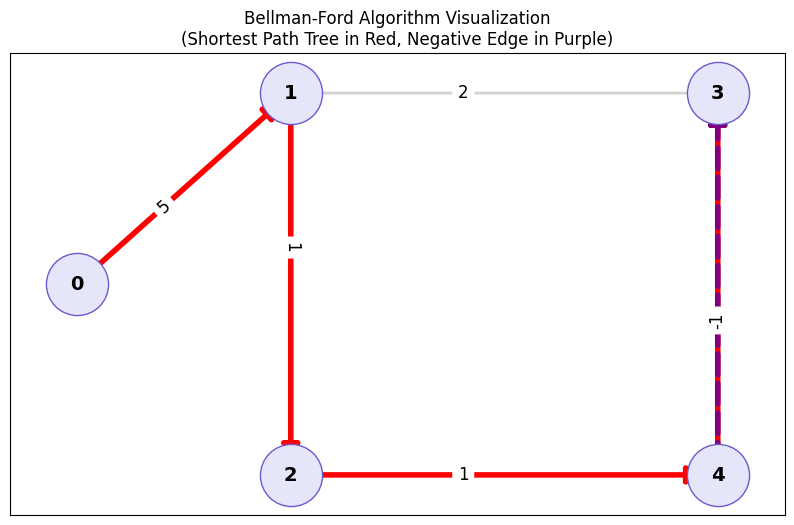

In [5]:
# Define the graph based on the assignment image
# Format: (source_node, destination_node, weight)
graph_edges = [
    (0, 1, 5),
    (1, 2, 1),
    (1, 3, 2),
    (2, 4, 1),
    (4, 3, -1)
]

total_vertices = 5
start_node = 0

# Execute the Bellman-Ford algorithm
final_distances, path_predecessors, neg_cycle = bellman_ford_algorithm(
    graph_edges,
    total_vertices,
    start_node
)

# Print the formal results
print("--- BELLMAN-FORD ALGORITHM RESULT ---")
print(f"Contains Negative Cycle: {neg_cycle}")
print("\nFinal Shortest Distances from Node 0:")
for node, distance in final_distances.items():
    pred = path_predecessors[node]
    print(f"Node {node}: Distance = {distance} | Predecessor = {pred}")
print("-" * 37)

# Graphical Visualization
G = nx.DiGraph()

# Add edges to the graph
for u, v, w in graph_edges:
    G.add_edge(u, v, weight=w)

# Define layout explicitly to match the image orientation
pos = {
    0: (0, 1),
    1: (1, 2),
    2: (1, 0),
    3: (3, 2),
    4: (3, 0)
}

plt.figure(figsize=(10, 6))
plt.title("Bellman-Ford Algorithm Visualization\n(Shortest Path Tree in Red, Negative Edge in Purple)")

# Draw all nodes
nx.draw_networkx_nodes(G, pos, node_color='lavender', node_size=2000, edgecolors='slateblue')
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# Separate edges by categories to color them differently
# Reconstruct the final shortest path tree based on predecessors
shortest_path_edges = []
for target_node, source_node in path_predecessors.items():
    if source_node is not None:
        shortest_path_edges.append((source_node, target_node))

# Draw the base edges (gray)
nx.draw_networkx_edges(G, pos, edge_color='lightgray', arrows=True, arrowsize=20, width=2)

# Highlight the shortest path tree (red)
nx.draw_networkx_edges(G, pos, edgelist=shortest_path_edges, edge_color='red', arrows=True, arrowsize=25, width=4)

# Highlight the negative edge explicitly to draw attention to it (purple)
negative_edges = [(u, v) for u, v, w in graph_edges if w < 0]
nx.draw_networkx_edges(G, pos, edgelist=negative_edges, edge_color='purple', style='dashed', arrows=True, arrowsize=25, width=4)

# Add edge weights labels
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12, label_pos=0.4)

plt.show()